# ASL Recognition with CNNs

This notebook implements a Convolutional Neural Network (CNN) for recognizing American Sign Language (ASL) gestures. We will compare the performance of a Fully Connected Neural Network (FCNN) with that of a CNN on the ASL dataset.

For more information on the ASL alphabet, you can refer to this site: https://www.asl.gs/

In [5]:
import random

import torch.nn as nn
import pandas as pd
import torch
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from tqdm import tqdm

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.cuda.is_available()

True

In [7]:
try:
    import google.colab
    IN_COLAB = True
except:
    IN_COLAB = False

data_base_path = "./data/asl/" if IN_COLAB else "./data/asl/"


### Load data

The data for the ASL dataset is stored in CSV files. It is already split into training, validation, and test sets. Each row in the CSV files contains pixel values for a 28x28 image (flattened into a single row) and a label indicating the ASL gesture.

The labels are integers from 0 to 23, corresponding to the letters A-Z (J and Z are excluded because they require movement).

The images are grayscale, so each pixel value ranges from 0 to 255.

In [8]:
train_df = pd.read_csv(data_base_path + "train.csv")
val_df = pd.read_csv(data_base_path + "val.csv")
test_df = pd.read_csv(data_base_path + "test.csv")

In [9]:
def label_to_letter(lbl):
    letter_code = ord('A') + int(lbl)
    return chr(letter_code) if letter_code < ord('J') else chr(letter_code + 1)

def show(img, lbl):
    i = img.reshape(28,28)
    plt.figure(figsize=(5,5))
    plt.title(label_to_letter(lbl), fontdict={'fontsize': 30})
    plt.axis('off')
    plt.imshow(i, cmap='gray')

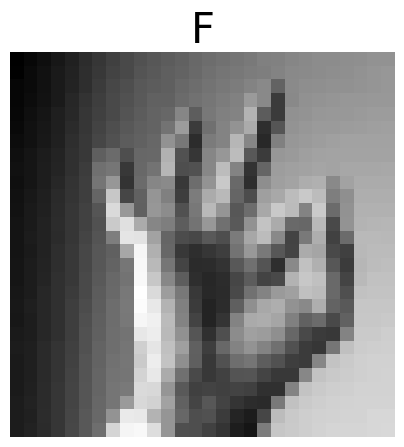

In [10]:
rnd_idx = random.choice(train_df.index)
image = train_df.iloc[rnd_idx].drop('label').values
label = train_df.iloc[rnd_idx]['label']
show(image, label)

## Preparing dataset

Let's start by creating the custom Dataset class for our ASL data. This class will take a DataFrame as input and will return the image and label for each sample. We will also normalize the pixel values to be between 0 and 1. The images will be reshaped as a 28x28 tensor with a single channel (grayscale).

In [11]:
IMG_HEIGHT = 28
IMG_WIDTH = 28
IMG_CHANNELS = 1

class AslDataset(Dataset):
    def __init__(self, base_df):
        x_df = base_df.copy()
        y_df = x_df.pop('label')
        x_df = x_df.values / 255
        x_df = x_df.reshape(-1, IMG_CHANNELS, IMG_WIDTH, IMG_HEIGHT)
        self.xs = torch.tensor(x_df).float().to(device)
        self.ys = torch.tensor(y_df).long().to(device)

    def __getitem__(self, idx):
        x = self.xs[idx]
        y = self.ys[idx]
        return x, y

    def __len__(self):
        return len(self.xs)

In [12]:
train_data = AslDataset(train_df)
val_data = AslDataset(val_df)
test_data = AslDataset(test_df)

In [13]:
batch_size = 32

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=True)

## Training functions

Now we can define our training functions. Since we will use accuracy to evaluate our model, we will create a function to calculate accuracy as well.

In [14]:
def get_batch_accuracy(output, y, N):
    pred = output.argmax(dim=1, keepdim=True)
    correct = pred.eq(y.view_as(pred)).sum().item()
    return correct / N

Our train function performs the full training loop. For each epoch, it computes the training loss and accuracy, and then evaluates the model on the validation set. It returns the history of training and validation losses and accuracies for plotting later.

In [15]:
def train(_model, _train_loader, _val_loader, _criterion, _optimizer, _num_epochs):
    res = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': [],
    }
    iterator = tqdm(range(epochs), desc="Training", unit="epoch")

    for _ in iterator:
        _model.train()
        train_loss = 0.0
        train_acc = 0.0
        for X_batch, y_batch in _train_loader:
            _optimizer.zero_grad()
            outputs = _model(X_batch)
            loss = _criterion(outputs, y_batch)
            loss.backward()
            _optimizer.step()
            train_loss += loss.item() * X_batch.size(0)
            train_acc += get_batch_accuracy(outputs, y_batch, len(_train_loader.dataset))

        epoch_train_loss = train_loss / len(_train_loader.dataset)

        _model.eval()
        val_loss = 0.0
        val_acc = 0.0
        with torch.no_grad():
            for X_val, y_val in _val_loader:
                val_outputs = _model(X_val)
                val_loss += _criterion(val_outputs, y_val).item() * X_val.size(0)
                val_acc += get_batch_accuracy(val_outputs, y_val, len(_val_loader.dataset))

        epoch_val_loss = val_loss / len(_val_loader.dataset)

        iterator.set_postfix(
            train_loss=f"{epoch_train_loss:.4f}",
            train_acc=f"{train_acc:.4f}",
            val_loss=f"{epoch_val_loss:.4f}",
            val_acc=f"{val_acc:.4f}",
        )

        res['train_loss'].append(epoch_train_loss)
        res['train_acc'].append(train_acc)
        res['val_loss'].append(epoch_val_loss)
        res['val_acc'].append(val_acc)

    return res

This test function will evaluate the model on the test set after training is complete. It will calculate the average loss and accuracy across the entire test set.

In [16]:
def test(_model, _test_loader, _loss_function):
    _model.eval()
    test_loss = 0.0
    test_acc = 0.0
    with torch.no_grad():
        for x, y in _test_loader:
            output = _model(x)
            test_loss += _loss_function(output, y).item() * x.size(0)
            test_acc += get_batch_accuracy(output, y, len(_test_loader.dataset))

    return (test_loss / len(_test_loader.dataset)), test_acc

## Training the models

### Baseline model - fully connected network

Before we implement the CNN, let's train a simple fully connected neural network (FCNN) as a baseline. This will help us understand the performance improvement that the CNN architecture provides for image data.

In [17]:
model_fcnn = nn.Sequential(
    nn.Flatten(),
    nn.Linear(IMG_HEIGHT * IMG_WIDTH, 512),
    nn.ReLU(),
    nn.Dropout(.3),

    nn.Linear(512, 512),
    nn.ReLU(),
    nn.Linear(512, 24)
)

model_fcnn = model_fcnn.to(device)

In [18]:
epochs = 20
loss_function = nn.CrossEntropyLoss()
optimizer = Adam(model_fcnn.parameters())

fcnn_res = train(model_fcnn, train_loader, val_loader, loss_function, optimizer, epochs)

Training: 100%|██████████| 20/20 [00:42<00:00,  2.12s/epoch, train_acc=0.8822, train_loss=0.3336, val_acc=0.7747, val_loss=0.9117]


In [19]:
fcnn_test_loss, fcnn_test_acc = test(model_fcnn, test_loader, loss_function)

### CNN model

Now let's implement a simple CNN architecture. We will use three convolutional layers followed by max pooling, and then a couple of fully connected layers before the output layer.

In [20]:
model_cnn = nn.Sequential(
    nn.Conv2d(IMG_CHANNELS, 25, 3, stride=1, padding=1),  # 25 x 28 x 28
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),  # 25 x 14 x 14

    nn.Conv2d(25, 50, 3, stride=1, padding=1),  # 50 x 14 x 14
    nn.ReLU(),
    nn.Dropout(.2),
    nn.MaxPool2d(2, stride=2),  # 50 x 7 x 7

    nn.Conv2d(50, 75, 3, stride=1, padding=1),  # 75 x 7 x 7
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),  # 75 x 3 x 3

    nn.Flatten(),
    nn.Linear(75 * 3 * 3, 512),
    nn.Dropout(.3),
    nn.ReLU(),
    nn.Linear(512, 24)
)

model_cnn = model_cnn.to(device)

In [21]:
epochs = 20
loss_function = nn.CrossEntropyLoss()
optimizer = Adam(model_cnn.parameters())

cnn_res = train(model_cnn, train_loader, val_loader, loss_function, optimizer, epochs)

Training: 100%|██████████| 20/20 [00:55<00:00,  2.76s/epoch, train_acc=0.9973, train_loss=0.0095, val_acc=0.9545, val_loss=0.2360]


In [22]:
cnn_test_loss, cnn_test_acc = test(model_cnn, test_loader, loss_function)

## Reflection section

### Which model is better at classifying ASL images?

In [23]:
df = pd.DataFrame({
    "Modelo": ["FCNN", "CNN"],
    "Test Loss": [fcnn_test_loss, cnn_test_loss],
    "Test Accuracy": [fcnn_test_acc, cnn_test_acc]
})

print(df)

  Modelo  Test Loss  Test Accuracy
0   FCNN   0.899149       0.780535
1    CNN   0.207146       0.954824


El mejor modelo es el que usa una red neuronal convolucional ya que se puede apreciar en los resultados de evaluación que tiene una función de pérdida mucho menor que la red FCNN, además de que el valor es bastante aceptable. Por otro lado, también se observa que en accuracy el el modelo CNN es considerablemente mejor que FCNN, con un resultado casi perfecto.

### Which model was _faster_ to train?

El modelo FCNN fue el más rápido, tardó 47 segundos, mientras que el modelo CNN tardó 55 segundos.

### Plot and compare the learning curves of both models. What do you observe about their training and validation performance over epochs?

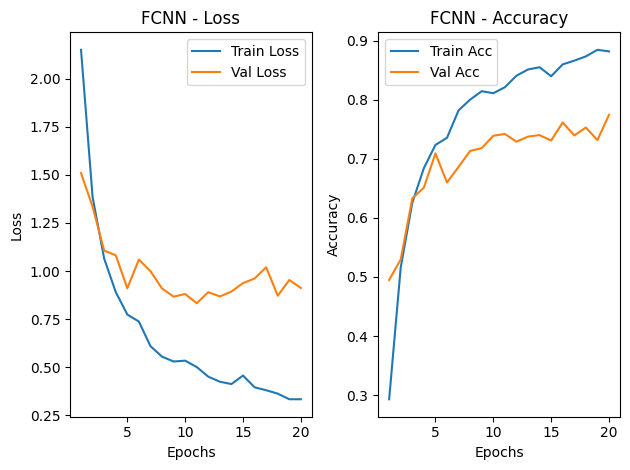

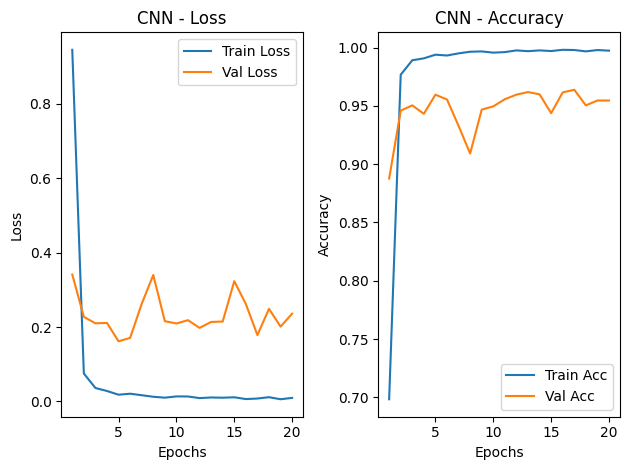

In [24]:
def plot_learning_curves(res, title="Modelo"):
    epochs = range(1, len(res['train_loss']) + 1)

    plt.figure()

    plt.subplot(1, 2, 1)
    plt.plot(epochs, res['train_loss'], label='Train Loss')
    plt.plot(epochs, res['val_loss'], label='Val Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title(f'{title} - Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, res['train_acc'], label='Train Acc')
    plt.plot(epochs, res['val_acc'], label='Val Acc')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title(f'{title} - Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_learning_curves(fcnn_res, title="FCNN")
plot_learning_curves(cnn_res, title="CNN")

Las curvas para ambos modelos siguieron un patrón similar, comenzaron con la pérdida en validación y entrenamiento decrementando, pero después de pocas épocas (menos de 5) la pérdida en validación dejó de disminuir tan drásticamente. En las siguientes épocas se observa que la pérdida en entrenamiento continua bajando pero la pérdida en validación comienza a subir y bajar, con una tendencia general a subir después de alcanzar el mínimo (época 12 en la FCNN y época 5 en la CNN). Esto muestra que se comenzó a sufrir de overfitting. A pesar de este comportamiento similar entre los dos modelos, es importante notar que la escala fue diferente, ya que se aprecia que para la CNN los valores de pérdida en validación se mantuvieron aproximadamente entre 0.1 y 0.4. Por otro lado, en el caso de la FCNN los valores estuvieron entre 0.75 y 1.5.

### How many trainable parameters does each model have?

Remember that each convolutional layer has $K \times (C_{in} \times k_h \times k_w + 1)$ parameters, where $K$ is the number of filters, $C_{in}$ is the number of input channels, $k_h$ and $k_w$ are the kernel height and width, and the +1 accounts for the bias term.

Each fully connected layer has $N_{in} \times N_{out} + N_{out}$ parameters, where $N_{in}$ is the number of input features and $N_{out}$ is the number of output features.

FCNN:
- Capa 1: (28 * 28) * 512 + 512 = 401920
- Capa 2: 512 * 512 + 512 = 262656
- Capa 3: 512 * 24 + 24 = 12312
- **Total**: 401920 + 262656 + 12312 = **676888 parametros**

CNN:
- Capa 1: 25 * (1 * 3 * 3 + 1) = 250
- Capa 2: 50 * (25 * 3 * 3 + 1) = 11300
- Capa 3: 75 * (50 * 3 * 3 + 1) = 33825
- Capa 4: (75 * 3 * 3) * 512 + 512 = 346112
- Capa 5: 512 * 24 + 24 = 12312
- **Total**: 250 + 11300 + 33825 + 346112 + 12312 = **403799 parametros**

### How do the models compare in terms of overfitting? Why do you think that is the case?

Por lo que se observa en las curvas de aprendizaje, se puede apreciar que ambos modelos presentan overfitting. Como se mencionó anteriormente, en ambos casos hay un punto en el que la pérdida en validación deja de bajar y comienza a subir poco a poco a comparación de la pérdida en entrenamiento que sigue bajando. Considero que esto pasa principalmente ya que el número de épocas es demasiado alto. Además, incluso aunque se utilice la técnica dropout, implementar early stopping podría ser muy beneficioso en este caso. De esta forma, no sería necesario disminuir el número de épocas, ya que el entrenamiento se detendría cuando se detectara overfitting.

Algo importante que se debe mencionar es que el aumento de la pérdida en validación para la FCNN no es tan claro, por lo que existe la posibilidad de que en realidad este valor siga disminuyendo lentamente en vez de aumentar. Si este es el caso, eso puede indicar que más bien le hicieron falta más épocas al modelo para poder generalizar mejor y tener mejores resultados; además de que en comparación del modelo CNN que tenía ya una pérdida en entrenamiento de menos de 0.1, el modelo FCNN terminó las épocas con un valor de más de 0.25.

### Final conclusions and remarks

A partir de esta actividad pude aprender cómo se implementa una red neuronal convolucional usando Pytorch. Visualizar una implementación ya hecha me permitió comprender cómo implementar correctamente capas convolucionales aplicadas a un modelo que recibe como entrada una imagen. También me permitió reforzar conceptos como el manejo de aplanamiento de las imágenes o el uso de capas intermedias como ReLu, Dropout o MaxPool. Otra cosa que pude aprender mediante esta activiad fue el cálculo del número de parámetros, tanto para capas completamente conectadas como para capas convolucionales; tema el cual no me había quedad muy claro en el parcial pasado. Finalmente, visualizar esta implementaión me permitió aplicar lo aprendido sobre overfitting para ser capaz de analizar los resultados e identificar este fenómeno. También, aunque no implementamos nada adicional, pude darme cuenta de que el análisis de este modelo y lo aprendido en clase me han dado herramients que puedo usar para solucionar el problema de overfitting. En este caso, mi solución sería implementar early stopping para identificar overfitting y detener el entrenamiento, usando al final el mejo modelo obtenido. El tener este tipo de actividades en las que el profesor nos proporciona un proyecto ya implementado me es especialmente útil ya que esto me sirve como una guía y orientación sobre cómo debería hacer mis propias implementaciones, dándome familiaridad con las herramientas que se usan y sirviendo como un template o base para mis propios proyectos. Se aprecian este tipo de actividades :)